In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt

from src.analysis import stochastic_contribution_analysis
from src.config import variable_names
from src.core import Variable
from src.models import OperatingIncomeModel, NetIncomeModel, MarketPriceModel
from src.variables import PriceToEarningsRatio
from src.visualization import generate_contribution_pie_chart
from src.utils import plot_multiple_views

In [2]:
variables = {
    variable_names.REVENUE: Variable(min=80000.0, exp=100000.0, max=120000.0),
    variable_names.COGS: Variable(min=30000.0, exp=40000.0, max=50000.0),
    variable_names.PE_RATIO: PriceToEarningsRatio(min=5.0, exp=8.0, max=10.0)
}

pipeline = [OperatingIncomeModel(), NetIncomeModel(), MarketPriceModel()]

breakdown = [variable_names.REVENUE, variable_names.COGS]
shuffled = [variable_names.REVENUE, variable_names.COGS]

In [3]:
contribution_analysis_report = stochastic_contribution_analysis(
    variables=variables,
    breakdown_metrics=breakdown,
    model_pipeline=pipeline,
    shuffled_inputs=shuffled,
    sample_size=100
)

print(contribution_analysis_report)

{'Revenue': 98269.44773400003, 'CostOfGoodSold': 39724.51844300001}


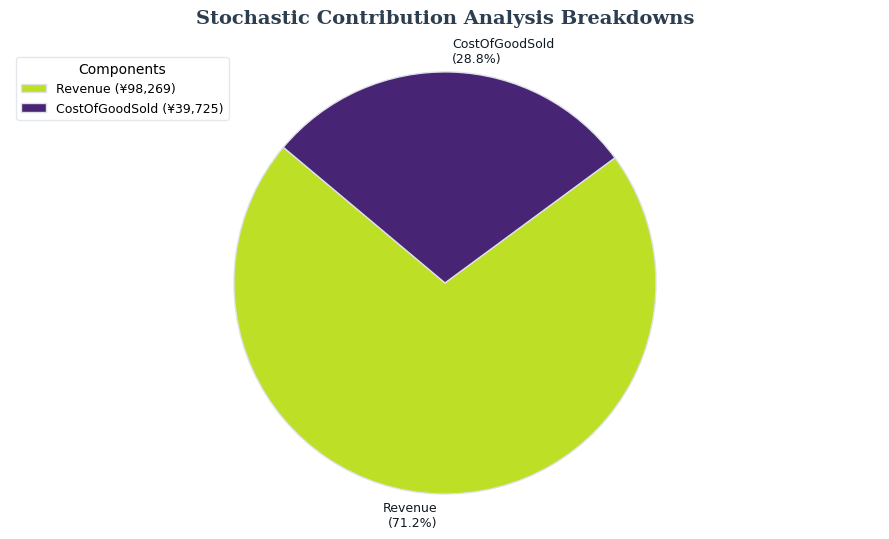

In [4]:
generate_contribution_pie_chart(contribution_analysis_report)

plt.show()
plt.close()

In [5]:
plot_functions = [
    lambda ax: generate_contribution_pie_chart(contribution_analysis_report, ax=ax, title="contribution"),
    lambda ax: generate_contribution_pie_chart(contribution_analysis_report, ax=ax),
]

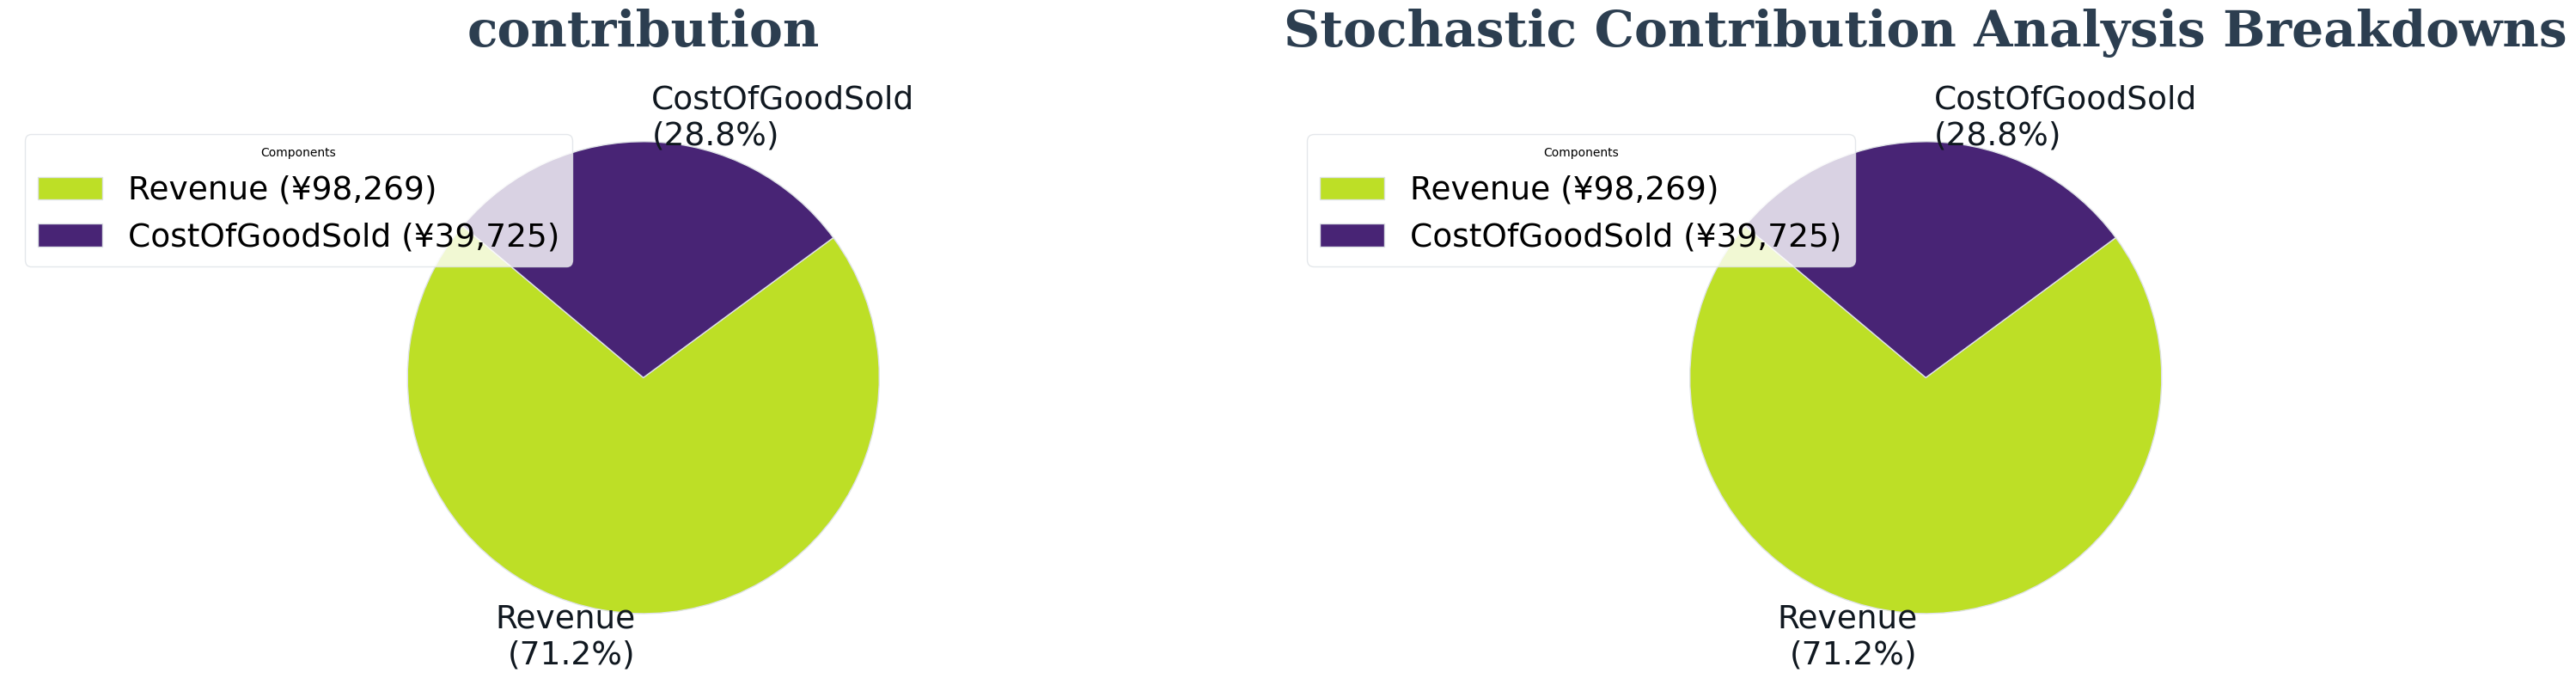

In [6]:
fig = plot_multiple_views(plot_functions)

In [7]:
plt.close()